In [1]:
import sys
sys.path.append("..")

import pandas as pd
import quantstats as qs
from data.loader import download_data, compute_returns
from backtester.engine import Backtester
from backtester.metrics import full_metrics

C:\Users\lenai\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
from backtester.signals import sma_crossover   

data = download_data("AAPL", "2018-01-01", "2024-01-01")
data = compute_returns(data)

signal = sma_crossover(data["Close"], fast=20, slow=50).fillna(0)  

bt     = Backtester(data, initial_capital=10000)
output = bt.run(signal)         
results = output["results"]

In [4]:
metrics = output["metrics"]

print("=" * 40)
print("   MÉTRIQUES COMPLÈTES")
print("=" * 40)
for k, v in metrics.items():
    print(f"{k:25} : {v}")


   MÉTRIQUES COMPLÈTES
CAGR (%)                  : 18.46
Sharpe                    : 0.89
Sortino                   : 1.03
Calmar                    : 0.63
Max Drawdown (%)          : -29.09
Win Rate (%)              : 52.84
Profit Factor             : 1.22
VaR 95% (%)               : -2.07
Capital final (€)         : 27555.82
Nb jours tradés           : 951
Nb trades                 : 16



Parameter       Value
--------------  ---------
Benchmark       Benchmark
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                           Benchmark    Strategy
-------------------------  -----------  ----------
Start Period               2018-03-16   2018-03-16
End Period                 2023-12-29   2023-12-29
Risk-Free Rate             0.0%         0.0%
Time in Market             100.0%       66.0%

Cumulative Return          91.11%       175.56%
CAGR﹪                     11.85%       19.15%

Sharpe                     0.65         0.91
Prob. Sharpe Ratio         93.88%       98.56%
Smart Sharpe               0.63         0.88
Sortino                    0.91         1.35
Smart Sortino              0.88         1.32
Sortino/√2                 0.64         0.96
Smart Sortino/√2           0.62         0.93
Omega                      1.13         1.22

Max Drawdown               -33.72%      -29.09%
Max DD Date                2020-03-23   20

None

,Start,Valley,End,Days,Max Drawdown,99% Max Drawdown
1,2022-01-04,2023-03-01,2023-12-29,725,-29.093519,-27.546659
2,2021-01-27,2021-05-12,2021-12-09,317,-22.633141,-21.246741
3,2020-09-02,2020-09-18,2021-01-22,143,-20.375606,-20.166937
4,2019-05-06,2019-08-05,2019-10-18,166,-18.611150,-16.211653
5,2020-02-13,2020-02-28,2020-06-05,114,-16.454769,-16.405881


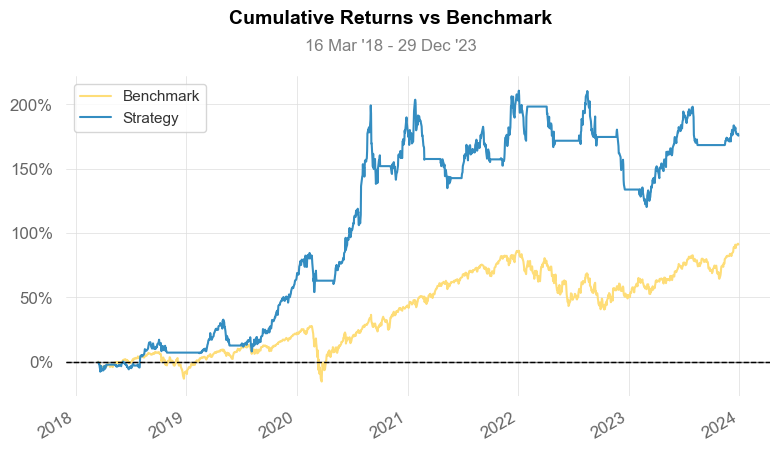

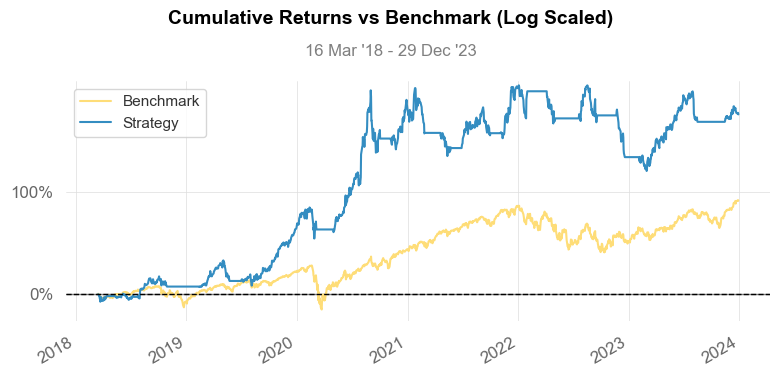

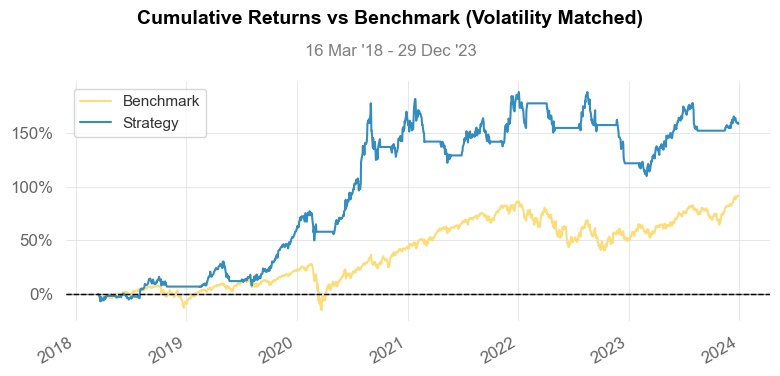

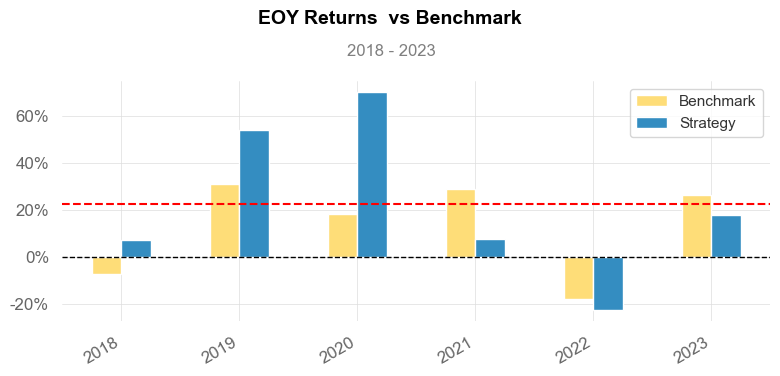

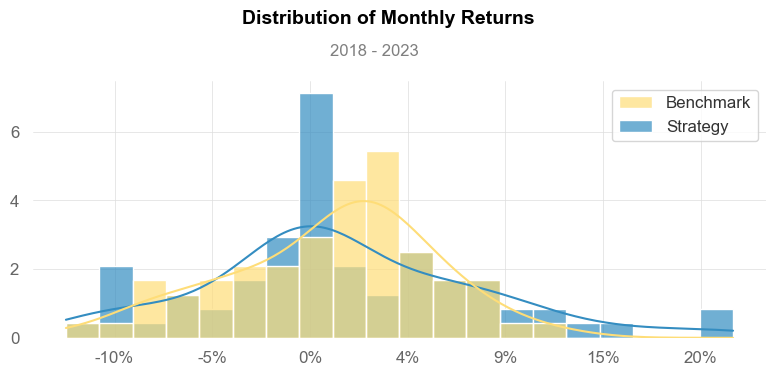

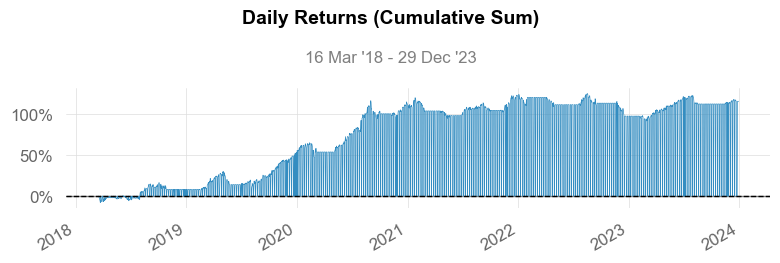

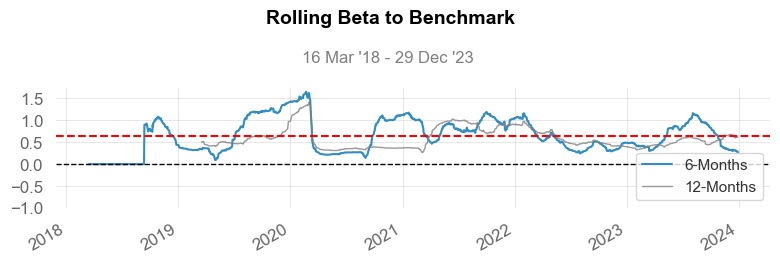

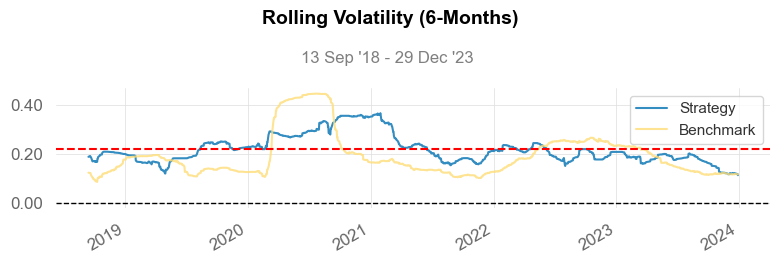

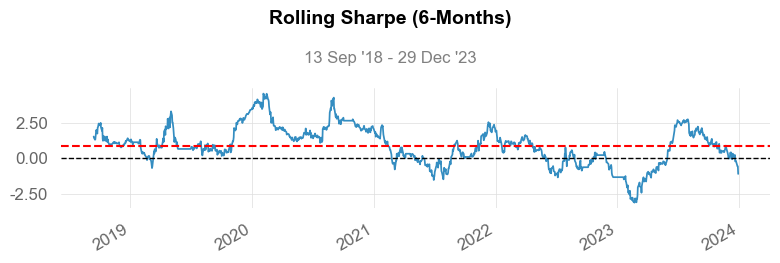

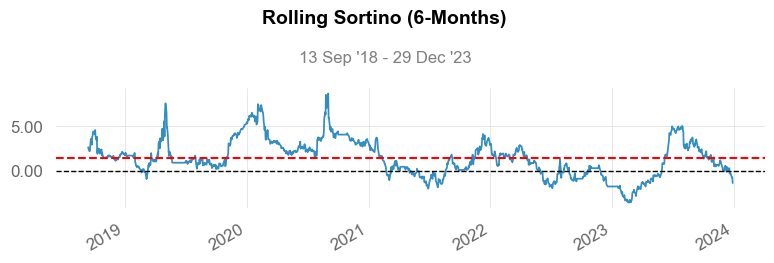

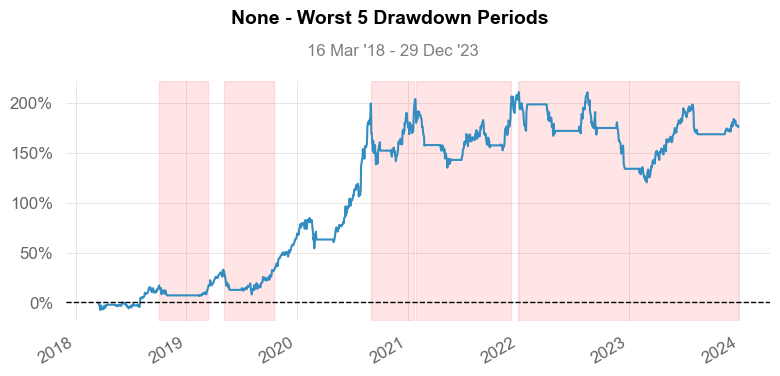

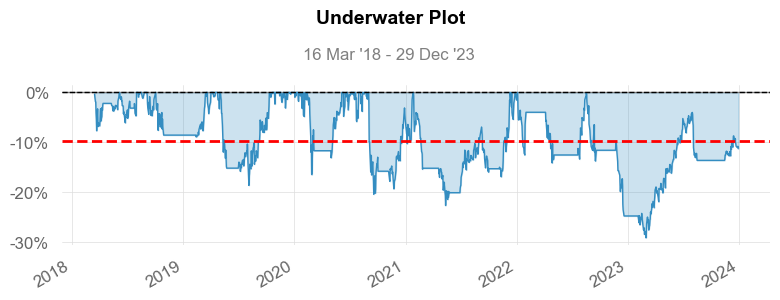

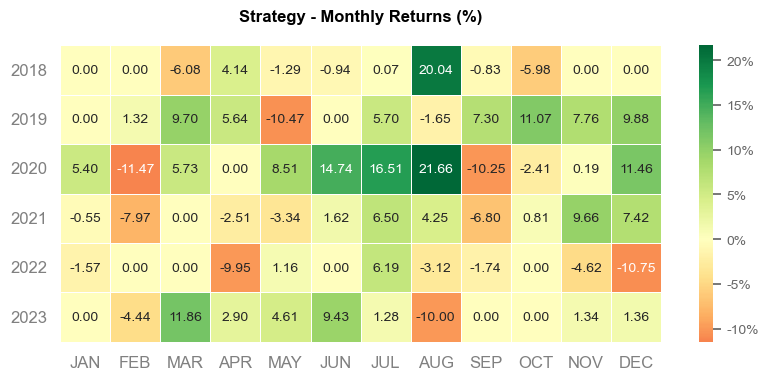

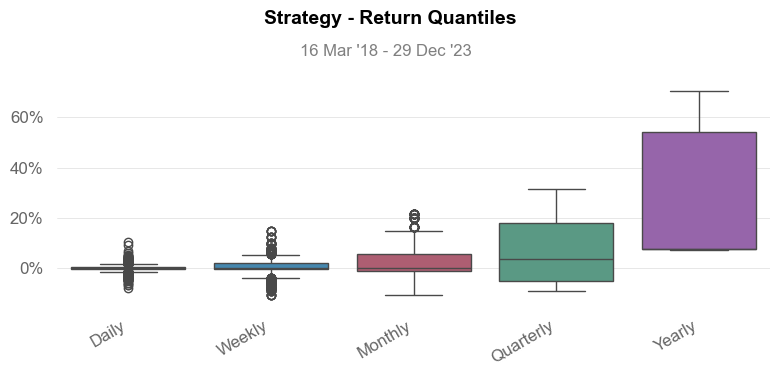

In [5]:
import os
os.makedirs("../reports", exist_ok=True)

strategy_returns = results["strategy_returns"].dropna()

# Affiche le tearsheet directement dans le notebook
qs.reports.full(strategy_returns, benchmark="SPY")

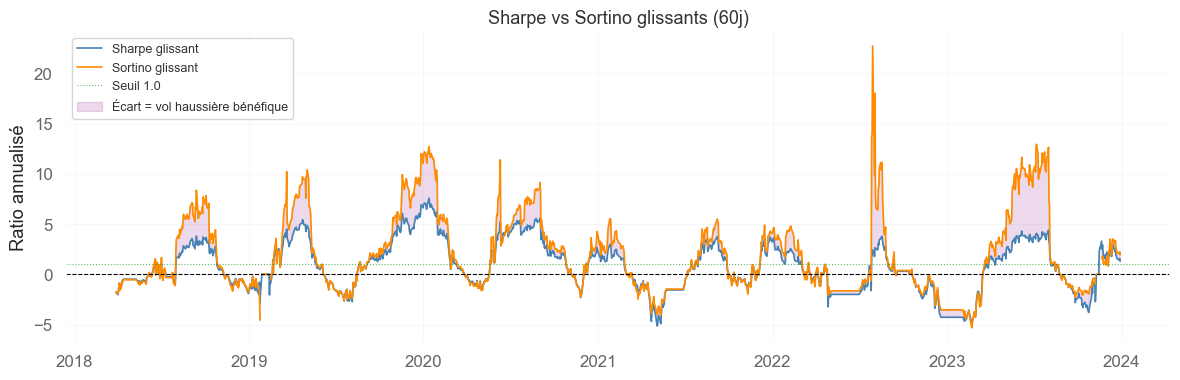

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("../reports", exist_ok=True)
strategy_returns = results["strategy_returns"].dropna()

# ─── GRAPHIQUE SORTINO vs SHARPE GLISSANT ────────────────────────────────────
# quantstats affiche le Sortino comme un chiffre unique dans son tableau.
# Ce graphique montre son ÉVOLUTION dans le temps sur 60 jours glissants.
# C'est ce que qs ne fait pas — on voit quand la stratégie se dégrade.

window = 60

rolling_sharpe = (
    strategy_returns
    .rolling(window)
    .apply(lambda r: (r.mean() / r.std()) * np.sqrt(252) if r.std() > 1e-10 else 0)
)

def _sortino(r):
    downside = r[r < 0]
    if len(downside) == 0 or downside.std() < 1e-10:
        return 0.0
    return (r.mean() / downside.std()) * np.sqrt(252)

rolling_sort = strategy_returns.rolling(window).apply(_sortino)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(rolling_sharpe.index, rolling_sharpe,
        label='Sharpe glissant', color='steelblue', linewidth=1.2)
ax.plot(rolling_sort.index, rolling_sort,
        label='Sortino glissant', color='darkorange', linewidth=1.2)
ax.axhline(0,   color='black',  linewidth=0.8, linestyle='--')
ax.axhline(1.0, color='green',  linewidth=0.8, linestyle=':', alpha=0.6, label='Seuil 1.0')
ax.fill_between(rolling_sharpe.index, rolling_sharpe, rolling_sort,
                alpha=0.15, color='purple',
                label='Écart = vol haussière bénéfique')
ax.set_title(f'Sharpe vs Sortino glissants ({window}j)', fontsize=13)
ax.set_ylabel('Ratio annualisé')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/sortino_vs_sharpe.png", dpi=150)
plt.show()



In [9]:
#On peut aussi appeler chaque métrique séparément
print(f"Sharpe (quantstats)  : {qs.stats.sharpe(strategy_returns):.2f}")
print(f"Sortino              : {qs.stats.sortino(strategy_returns):.2f}")
print(f"Max Drawdown         : {qs.stats.max_drawdown(strategy_returns)*100:.2f}%")
print(f"Volatilité annuelle  : {qs.stats.volatility(strategy_returns)*100:.2f}%")
print(f"CAGR                 : {qs.stats.cagr(strategy_returns)*100:.2f}%")

Sharpe (quantstats)  : 0.89
Sortino              : 1.33
Max Drawdown         : -29.09%
Volatilité annuelle  : 21.65%
CAGR                 : 18.46%
